In [2]:
# ============================================================
# Cell 1 — Imports
# ============================================================

import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent

sys.path.append(str(BASE_DIR))

import numpy as np
import pandas as pd
import pickle

import torch
import matplotlib.pyplot as plt

from models.temporal_vae import TemporalVAE
from models.latent_transformer import LatentTransformer

In [3]:
# ============================================================
# Cell 2 — Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [4]:
# ============================================================
# Cell 3 — User Configuration
# ============================================================

# CHANGE COMPANY HERE

COMPANY_FILE = (
    BASE_DIR /
    "company_data" /
    "241.csv"
)

# ==========================================
# Historical Window Length
# ==========================================

WINDOW_LENGTH = 12

# ==========================================
# Prediction Month
# ==========================================
# This predicts THIS month
# using all PREVIOUS months
# ==========================================

PREDICTION_MONTH = "2024-06-01"

In [5]:
# ============================================================
# Cell 4 — Hyperparameters
# ============================================================

HIDDEN_DIM = 128

LATENT_DIM = 32

NUM_TOKENS = 8

TOKEN_DIM = 4

In [6]:
# ============================================================
# Cell 5 — Load Metadata
# ============================================================

with open(
    BASE_DIR / "processed" / "metadata.pkl",
    "rb"
) as f:

    metadata = pickle.load(f)

feature_columns = metadata["feature_columns"]

num_features = metadata["num_features"]

print(num_features)

45


In [7]:
# ============================================================
# Cell 6 — Load VAE
# ============================================================

vae = TemporalVAE(
    input_dim=num_features,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM
)

vae.load_state_dict(
    torch.load(
        BASE_DIR / "checkpoints" / "temporal_vae.pt",
        map_location=device
    )
)

vae = vae.to(device)

vae.eval()

print("VAE Loaded")

VAE Loaded


In [8]:
# ============================================================
# Cell 7 — Load Transformer
# ============================================================

transformer = LatentTransformer(
    latent_dim=LATENT_DIM,
    num_tokens=NUM_TOKENS,
    token_dim=TOKEN_DIM
)

transformer.load_state_dict(
    torch.load(
        BASE_DIR / "checkpoints" / "latent_transformer.pt",
        map_location=device
    )
)

transformer = transformer.to(device)

transformer.eval()

print("Transformer Loaded")

Transformer Loaded


In [9]:
# ============================================================
# Cell 8 — Load Company Data
# ============================================================

df = pd.read_csv(COMPANY_FILE)

print(df.head())

   co_code       Month  monthly_gross_return    mktcap  price  \
0      241  2022-09-01              0.846719  897.8760  70.00   
1      241  2022-10-01              0.964055  865.8090  67.50   
2      241  2022-11-01              1.074802  930.5843  72.55   
3      241  2022-12-01              0.824959  767.6840  59.85   
4      241  2023-01-01              1.040930  799.1096  62.30   

   equity_bv_on_stkdate  fy_book_value     lag_mv    BM_sep Size_Label  ...  \
0                 238.3          229.4  1060.3488  0.465971          S  ...   
1                 238.3          229.4   897.8760  0.265404          S  ...   
2                 238.3          229.4   865.8090  0.265404          S  ...   
3                 238.3          229.4   930.5843  0.265404          S  ...   
4                 245.9          229.4   767.6840  0.265404          S  ...   

  lagged_book_equity_missing  lagged_assets_missing  lagged2_assets_missing  \
0                          1                      1    

In [10]:
# ============================================================
# Cell 9 — Chronological Sorting
# ============================================================

df["Month"] = pd.to_datetime(df["Month"])

df = df.sort_values("Month")

df = df.reset_index(drop=True)

print(df[["Month"]].tail())

        Month
26 2024-11-01
27 2024-12-01
28 2025-01-01
29 2025-02-01
30 2025-03-01


In [11]:
# ============================================================
# Cell 10 — Locate Prediction Month
# ============================================================

prediction_month = pd.to_datetime(
    PREDICTION_MONTH
)

prediction_index = df.index[
    df["Month"] == prediction_month
][0]

print(prediction_index)

21


In [12]:
# ============================================================
# Cell 11 — Build Historical Window
# ============================================================

start_index = max(
    0,
    prediction_index - WINDOW_LENGTH
)

historical_df = df.iloc[
    start_index:prediction_index
]

print(
    historical_df[
        ["Month"]
    ]
)

        Month
9  2023-06-01
10 2023-07-01
11 2023-08-01
12 2023-09-01
13 2023-10-01
14 2023-11-01
15 2023-12-01
16 2024-01-01
17 2024-02-01
18 2024-03-01
19 2024-04-01
20 2024-05-01


In [13]:
# ============================================================
# Cell 12 — Add Missing Columns
# ============================================================

for col in feature_columns:

    if col not in historical_df.columns:

        historical_df[col] = 0

In [14]:
# ============================================================
# Cell 13 — Build Feature Array
# ============================================================

feature_df = historical_df[
    feature_columns
]

feature_array = feature_df.values.astype(
    np.float32
)

print(feature_array.shape)

(12, 45)


In [15]:
# ============================================================
# Cell 14 — Padding
# ============================================================

sequence = np.zeros(
    (WINDOW_LENGTH, num_features),
    dtype=np.float32
)

seq_len = len(feature_array)

sequence[-seq_len:] = feature_array

print(sequence.shape)

(12, 45)


In [16]:
# ============================================================
# Cell 15 — Tensor Conversion
# ============================================================

x = torch.tensor(
    sequence,
    dtype=torch.float32
).unsqueeze(0)

x = x.to(device)

print(x.shape)

torch.Size([1, 12, 45])


In [17]:
# ============================================================
# Cell 16 — Latent Extraction
# ============================================================

with torch.no_grad():

    mu, logvar = vae.encode(x)

print(mu.shape)

torch.Size([1, 32])


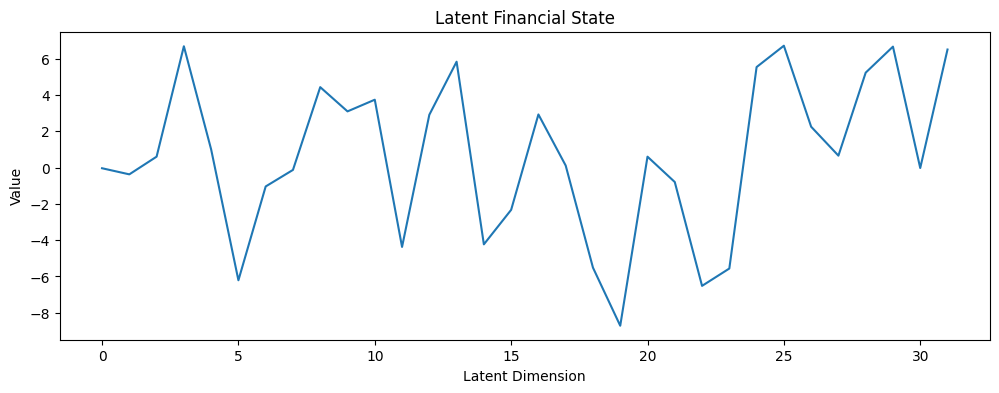

In [18]:
# ============================================================
# Cell 17 — Latent Visualization
# ============================================================

latent_vector = mu.cpu().numpy()[0]

plt.figure(figsize=(12,4))

plt.plot(latent_vector)

plt.title("Latent Financial State")

plt.xlabel("Latent Dimension")

plt.ylabel("Value")

plt.show()

In [19]:
# ============================================================
# Cell 18 — Transformer Prediction
# ============================================================

with torch.no_grad():

    prediction = transformer(mu)

prediction = prediction.item()

print("Predicted Gross Return:")

print(prediction)

Predicted Gross Return:
1.0215619802474976


In [20]:
# ============================================================
# Cell 19 — Actual Return
# ============================================================

actual_return = df.iloc[
    prediction_index
]["monthly_gross_return"]

print("Actual Return:")

print(actual_return)

Actual Return:
1.123425393594879


In [21]:
# ============================================================
# Cell 20 — Absolute Error
# ============================================================

absolute_error = abs(
    prediction - actual_return
)

print("Absolute Error:")

print(absolute_error)

Absolute Error:
0.10186341334738147


In [22]:
# ============================================================
# Cell 21 — Rolling Inference
# ============================================================

predictions = []

actuals = []

months = []

In [23]:
# ============================================================
# Cell 22 — Run Rolling Predictions
# ============================================================

with torch.no_grad():

    for idx in range(1, len(df)):

        start_idx = max(
            0,
            idx - WINDOW_LENGTH
        )

        history = df.iloc[
            start_idx:idx
        ]

        for col in feature_columns:

            if col not in history.columns:

                history[col] = 0

        features = history[
            feature_columns
        ].values.astype(np.float32)

        seq = np.zeros(
            (WINDOW_LENGTH, num_features),
            dtype=np.float32
        )

        seq[-len(features):] = features

        tensor = torch.tensor(
            seq,
            dtype=torch.float32
        ).unsqueeze(0)

        tensor = tensor.to(device)

        mu, _ = vae.encode(tensor)

        pred = transformer(mu)

        pred = pred.item()

        predictions.append(pred)

        actuals.append(
            df.iloc[idx][
                "monthly_gross_return"
            ]
        )

        months.append(
            df.iloc[idx]["Month"]
        )

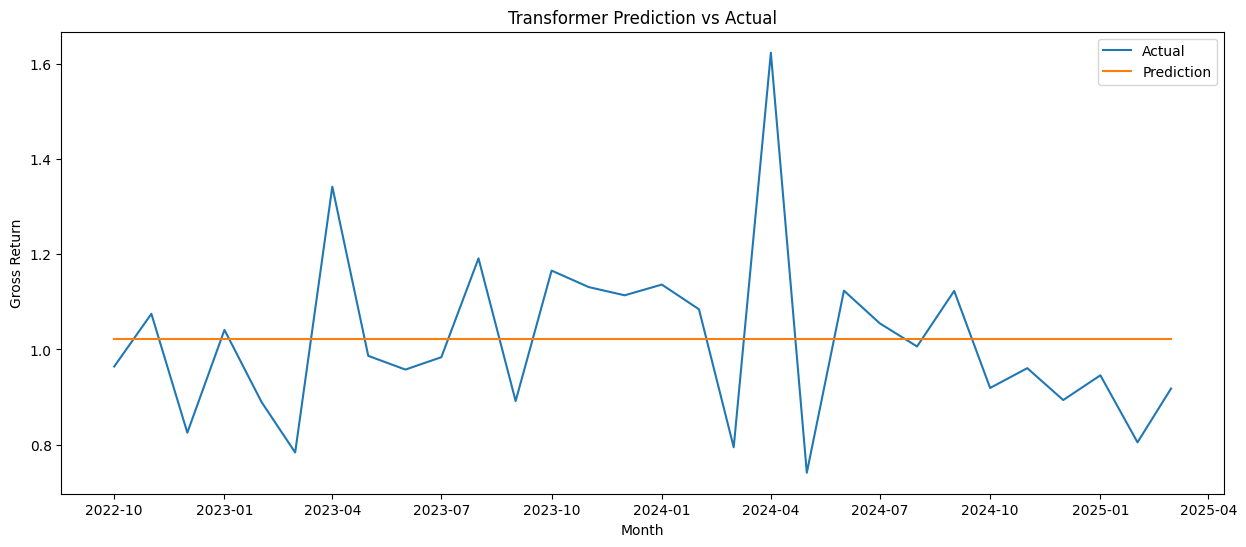

In [24]:
# ============================================================
# Cell 23 — Prediction Plot
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    months,
    actuals,
    label="Actual"
)

plt.plot(
    months,
    predictions,
    label="Prediction"
)

plt.title(
    "Transformer Prediction vs Actual"
)

plt.xlabel("Month")

plt.ylabel("Gross Return")

plt.legend()

plt.show()

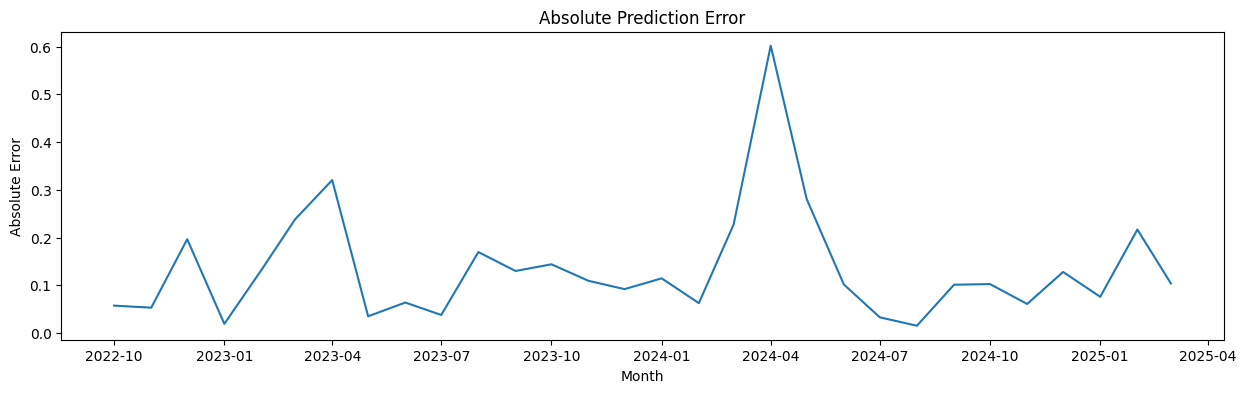

In [25]:
# ============================================================
# Cell 24 — Absolute Error Plot
# ============================================================

errors = np.abs(
    np.array(predictions) -
    np.array(actuals)
)

plt.figure(figsize=(15,4))

plt.plot(
    months,
    errors
)

plt.title(
    "Absolute Prediction Error"
)

plt.xlabel("Month")

plt.ylabel("Absolute Error")

plt.show()

In [26]:
# ============================================================
# Cell 25 — Prediction DataFrame
# ============================================================

results_df = pd.DataFrame({

    "Month": months,

    "Prediction": predictions,

    "Actual": actuals,

    "Absolute_Error": errors
})

results_df.head(20)

,Month,Prediction,Actual,Absolute_Error
0,2022-10-01,1.021562,0.964055,0.057507
1,2022-11-01,1.021562,1.074802,0.053240
2,2022-12-01,1.021562,0.824959,0.196603
3,2023-01-01,1.021562,1.040930,0.019368
4,2023-02-01,1.021562,0.889109,0.132453
5,2023-03-01,1.021562,0.783390,0.238172
6,2023-04-01,1.021562,1.342006,0.320444
7,2023-05-01,1.021562,0.986419,0.035143
8,2023-06-01,1.021562,0.957575,0.063987
9,2023-07-01,1.021562,0.983597,0.037965


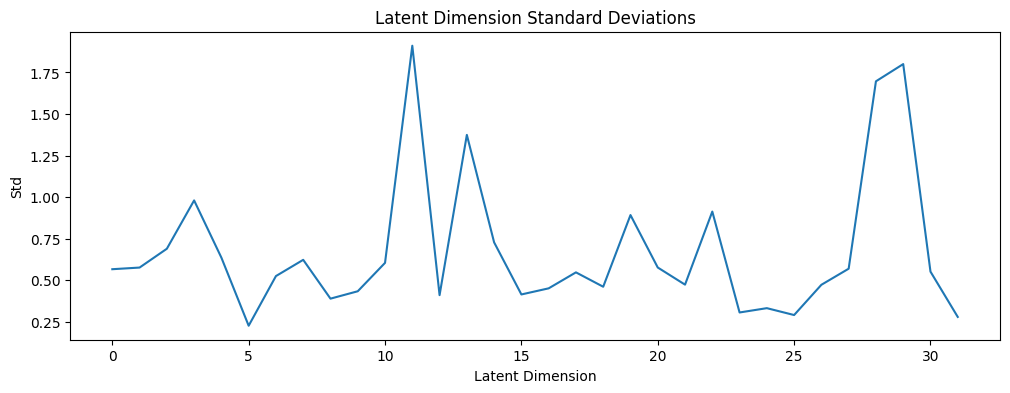

[0.5653689  0.5752963  0.68861693 0.979632   0.6349948  0.2250777
 0.52408415 0.6218517  0.38811424 0.4326064  0.60360444 1.9111336
 0.4091718  1.374242   0.7270191  0.4133492  0.45017642 0.54639447
 0.45984903 0.89147085 0.5756571  0.47241172 0.9124595  0.30485177
 0.3308498  0.28941926 0.47159842 0.5684297  1.6968703  1.8005252
 0.5507809  0.27801114]


In [27]:
latent_mu = np.load(
    BASE_DIR / "processed" / "latent_mu.npy"
)

latent_std = np.std(
    latent_mu,
    axis=0
)

plt.figure(figsize=(12,4))

plt.plot(latent_std)

plt.title(
    "Latent Dimension Standard Deviations"
)

plt.xlabel("Latent Dimension")

plt.ylabel("Std")

plt.show()

print(latent_std)


DATASET INFO
Latent shape: (567307, 32)
Targets shape: (567307,)

LATENT VARIANCE
[0.5653689  0.5752963  0.68861693 0.979632   0.6349948  0.2250777
 0.52408415 0.6218517  0.38811424 0.4326064  0.60360444 1.9111336
 0.4091718  1.374242   0.7270191  0.4133492  0.45017642 0.54639447
 0.45984903 0.89147085 0.5756571  0.47241172 0.9124595  0.30485177
 0.3308498  0.28941926 0.47159842 0.5684297  1.6968703  1.8005252
 0.5507809  0.27801114]

Min Std: 0.2250777
Max Std: 1.9111336
Mean Std: 0.67731


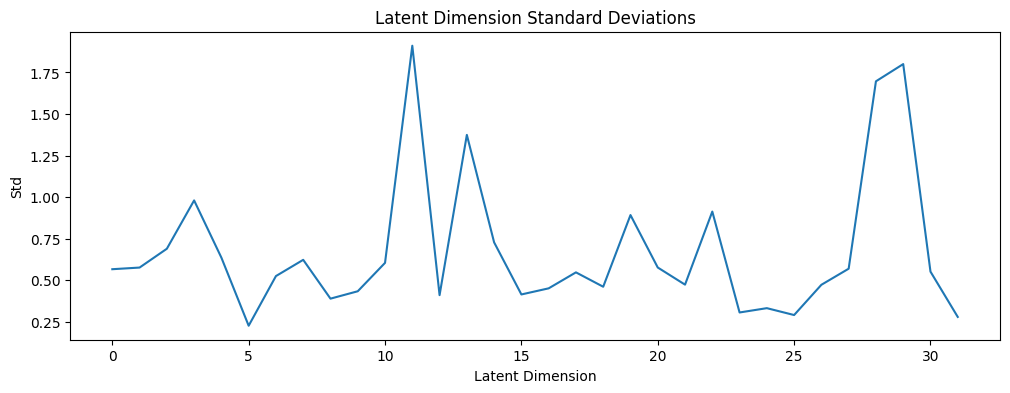


DEAD LATENT DIMENSIONS
Dead Dimensions (<0.05 std): 0

TARGET DISTRIBUTION
count    567307.000000
mean          1.021953
std           0.191258
min           0.021402
25%           0.919789
50%           0.998611
75%           1.091993
max           5.803527
dtype: float64


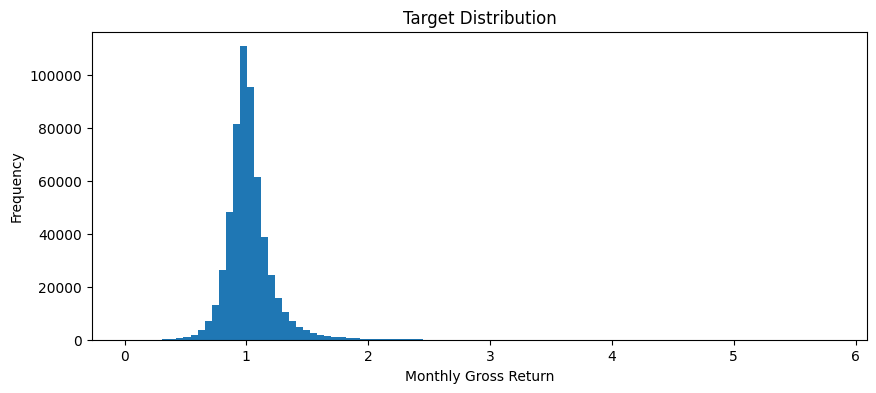


TRANSFORMER PREDICTIONS
count    30.000000
mean      1.021562
std       0.000000
min       1.021562
25%       1.021562
50%       1.021562
75%       1.021562
max       1.021562
dtype: float64


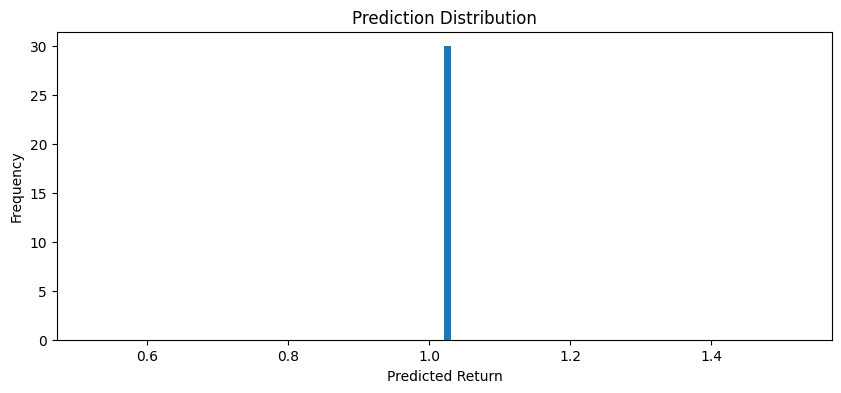


VARIANCE COMPARISON
Prediction Std: 0.0
Target Std: 0.37469393

CORRELATION
nan

DIRECTIONAL ACCURACY
1.0

PCA ANALYSIS
Explained Variance Ratio:
[0.6958442  0.23104215]


/home/mushu/GitHub/IML_project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/mushu/GitHub/IML_project/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


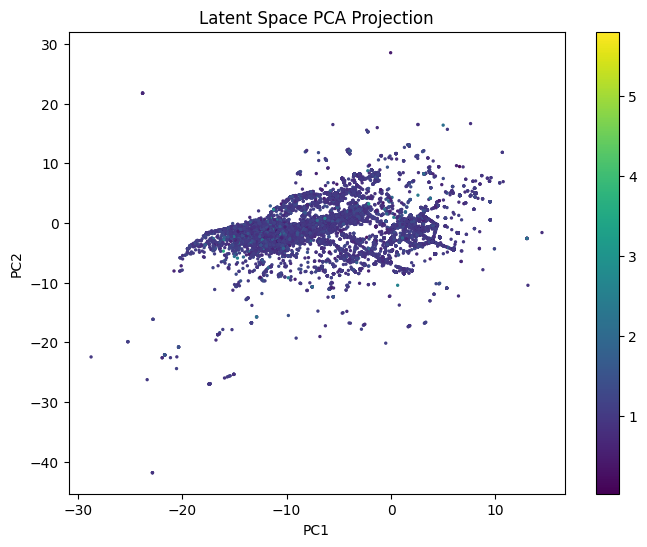


LINEAR DECODABILITY TEST
Linear Regression MSE:
0.03689587488770485

Linear Regression Correlation:
0.03812836039410348

LATENT/TARGET CORRELATIONS
[-0.03076297 -0.0328934   0.03244727 -0.01948437  0.03024041 -0.00940126
 -0.03074889  0.03319363  0.02584203  0.0257226   0.02979685  0.01686068
  0.02549445 -0.01827496  0.00507225 -0.02690702  0.03068047 -0.03053172
 -0.00577841  0.02065092  0.03297631 -0.030675    0.01533321 -0.01386526
  0.01460291  0.0018045   0.03292164  0.03428038 -0.01777828 -0.01766369
  0.03116763  0.0177807 ]


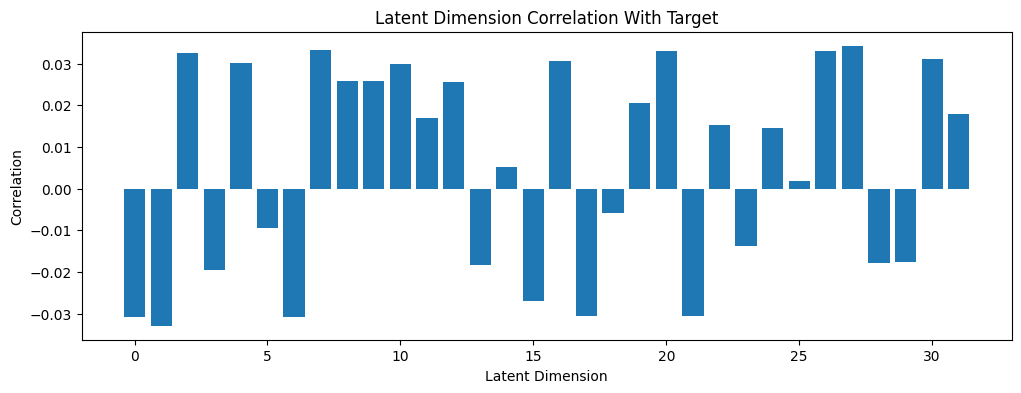


TOP LATENT DIMENSIONS
Dimension 27: 0.0343
Dimension 7: 0.0332
Dimension 20: 0.0330
Dimension 26: 0.0329
Dimension 1: -0.0329

DIAGNOSTIC SUMMARY
- Predictor collapsed to mean prediction
- Latent space appears active
- Latent dimensions weakly correlated with target

Diagnostics complete.


In [29]:
# ============================================================
# COMPREHENSIVE LATENT + PREDICTION DIAGNOSTICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# ============================================================
# LOAD DATA
# ============================================================

latent_mu = np.load(
    BASE_DIR / "processed" / "latent_mu.npy"
)

targets = np.load(
    BASE_DIR / "processed" / "y.npy"
)

print("\n==============================")
print("DATASET INFO")
print("==============================")

print("Latent shape:", latent_mu.shape)
print("Targets shape:", targets.shape)

# ============================================================
# LATENT VARIANCE ANALYSIS
# ============================================================

latent_std = np.std(
    latent_mu,
    axis=0
)

print("\n==============================")
print("LATENT VARIANCE")
print("==============================")

print(latent_std)

print("\nMin Std:", latent_std.min())
print("Max Std:", latent_std.max())
print("Mean Std:", latent_std.mean())

plt.figure(figsize=(12,4))

plt.plot(latent_std)

plt.title(
    "Latent Dimension Standard Deviations"
)

plt.xlabel("Latent Dimension")

plt.ylabel("Std")

plt.show()

# ============================================================
# DEAD DIMENSIONS
# ============================================================

dead_dims = np.sum(
    latent_std < 0.05
)

print("\n==============================")
print("DEAD LATENT DIMENSIONS")
print("==============================")

print(
    f"Dead Dimensions (<0.05 std): "
    f"{dead_dims}"
)

# ============================================================
# TARGET DISTRIBUTION
# ============================================================

print("\n==============================")
print("TARGET DISTRIBUTION")
print("==============================")

print(pd.Series(targets).describe())

plt.figure(figsize=(10,4))

plt.hist(
    targets,
    bins=100
)

plt.title(
    "Target Distribution"
)

plt.xlabel(
    "Monthly Gross Return"
)

plt.ylabel("Frequency")

plt.show()

# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

print("\n==============================")
print("TRANSFORMER PREDICTIONS")
print("==============================")

transformer_predictions = np.array(
    predictions
)

print(
    pd.Series(
        transformer_predictions
    ).describe()
)

plt.figure(figsize=(10,4))

plt.hist(
    transformer_predictions,
    bins=100
)

plt.title(
    "Prediction Distribution"
)

plt.xlabel("Predicted Return")

plt.ylabel("Frequency")

plt.show()

# ============================================================
# PREDICTION VARIANCE
# ============================================================

prediction_std = np.std(
    transformer_predictions
)

target_std = np.std(
    targets[:len(transformer_predictions)]
)

print("\n==============================")
print("VARIANCE COMPARISON")
print("==============================")

print(
    "Prediction Std:",
    prediction_std
)

print(
    "Target Std:",
    target_std
)

# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation = np.corrcoef(
    transformer_predictions,
    actuals
)[0,1]

print("\n==============================")
print("CORRELATION")
print("==============================")

print(correlation)

# ============================================================
# DIRECTIONAL ACCURACY
# ============================================================

directional_accuracy = np.mean(

    np.sign(transformer_predictions)
    ==
    np.sign(actuals)
)

print("\n==============================")
print("DIRECTIONAL ACCURACY")
print("==============================")

print(directional_accuracy)

# ============================================================
# PCA ANALYSIS
# ============================================================

print("\n==============================")
print("PCA ANALYSIS")
print("==============================")

pca = PCA(n_components=2)

latent_2d = pca.fit_transform(
    latent_mu
)

print(
    "Explained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,6))

scatter = plt.scatter(

    latent_2d[:,0],
    latent_2d[:,1],

    c=targets,

    s=2
)

plt.colorbar(scatter)

plt.title(
    "Latent Space PCA Projection"
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

# ============================================================
# LINEAR DECODABILITY TEST
# ============================================================

print("\n==============================")
print("LINEAR DECODABILITY TEST")
print("==============================")

X_train, X_test, y_train, y_test = train_test_split(

    latent_mu,
    targets,

    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_corr = np.corrcoef(
    linear_predictions,
    y_test
)[0,1]

print("Linear Regression MSE:")
print(linear_mse)

print("\nLinear Regression Correlation:")
print(linear_corr)

# ============================================================
# LATENT DIMENSION CORRELATIONS
# ============================================================

print("\n==============================")
print("LATENT/TARGET CORRELATIONS")
print("==============================")

dimension_correlations = []

for i in range(latent_mu.shape[1]):

    corr = np.corrcoef(

        latent_mu[:,i],
        targets

    )[0,1]

    dimension_correlations.append(corr)

dimension_correlations = np.array(
    dimension_correlations
)

print(dimension_correlations)

plt.figure(figsize=(12,4))

plt.bar(

    np.arange(len(dimension_correlations)),
    dimension_correlations
)

plt.title(
    "Latent Dimension Correlation With Target"
)

plt.xlabel("Latent Dimension")

plt.ylabel("Correlation")

plt.show()

# ============================================================
# TOP CORRELATED DIMENSIONS
# ============================================================

top_dims = np.argsort(
    np.abs(dimension_correlations)
)[::-1][:5]

print("\n==============================")
print("TOP LATENT DIMENSIONS")
print("==============================")

for dim in top_dims:

    print(
        f"Dimension {dim}: "
        f"{dimension_correlations[dim]:.4f}"
    )

# ============================================================
# FINAL DIAGNOSIS
# ============================================================

print("\n==============================")
print("DIAGNOSTIC SUMMARY")
print("==============================")

if prediction_std < 0.01:

    print(
        "- Predictor collapsed to mean prediction"
    )

if dead_dims > 10:

    print(
        "- Possible latent collapse"
    )
else:

    print(
        "- Latent space appears active"
    )

if abs(correlation) < 0.05:

    print(
        "- Weak predictive relationship"
    )

if np.max(np.abs(dimension_correlations)) < 0.1:

    print(
        "- Latent dimensions weakly correlated "
        "with target"
    )

print("\nDiagnostics complete.")